In [2]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 1.2 MB/s  0:00:021.1 MB/s eta 0:00:01:020m


In [3]:
# ============================================================
# 0. Preparación del ambiente
# Proyecto 5 - SARS-CoV-2 NC_045512.2
# Autora: Valeria Contreras Saldivar
# UEA: Cómputo Científico
# ============================================================

import sys
import subprocess
import importlib.util

# Función pequeña para instalar paquetes si hacen falta.
def instalar_si_falta(paquete, nombre_import=None):
    if nombre_import is None:
        nombre_import = paquete
    if importlib.util.find_spec(nombre_import) is None:
        print(f"Instalando {paquete}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", paquete])
    else:
        print(f"{paquete} ya está instalado.")

instalar_si_falta("biopython", "Bio")

from pathlib import Path
from collections import Counter
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Bio import Entrez, SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

# Carpeta donde se guardarán los archivos descargados y generados.
DATA_DIR = Path("data_sars_cov_2")
DATA_DIR.mkdir(exist_ok=True)

# Configuración visual básica para las gráficas.
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

print("Carpeta de trabajo:", DATA_DIR.resolve())

biopython ya está instalado.
Carpeta de trabajo: /Users/valeriacontreras/Downloads/data_sars_cov_2


In [5]:
# ============================================================
# 1. Descargar el registro GenBank de SARS-CoV-2
# ============================================================

ACCESSION = "NC_045512.2"

Entrez.email = "valeriasaldivar005@gmail.com"

gb_file = DATA_DIR / f"{ACCESSION}.gb"

if not gb_file.exists():
    print(f"Descargando {ACCESSION} desde NCBI...")
    with Entrez.efetch(db="nuccore", id=ACCESSION, rettype="gb", retmode="text") as handle:
        gb_data = handle.read()
    gb_file.write_text(gb_data)
    print("Descarga completada:", gb_file)
else:
    print("El archivo ya existía. Se usará la copia local:", gb_file)

# Leer el archivo GenBank
record = SeqIO.read(gb_file, "genbank")

# Convertimos la secuencia a texto y usamos T en lugar de U, como en el artículo.
genome_seq = str(record.seq).upper().replace("U", "T")

print("ID:", record.id)
print("Nombre:", record.name)
print("Descripción:", record.description)
print("Longitud del genoma:", len(genome_seq), "nt")
print("Organismo:", record.annotations.get("organism", "No disponible"))

El archivo ya existía. Se usará la copia local: data_sars_cov_2/NC_045512.2.gb
ID: NC_045512.2
Nombre: NC_045512
Descripción: Severe acute respiratory syndrome coronavirus 2 isolate Wuhan-Hu-1, complete genome
Longitud del genoma: 29903 nt
Organismo: Severe acute respiratory syndrome coronavirus 2


In [6]:
# ============================================================
# 2. Guardar genoma completo en FASTA
# ============================================================

genome_fasta = DATA_DIR / f"{ACCESSION}_genoma_completo.fasta"

genome_record = SeqRecord(
    Seq(genome_seq),
    id=ACCESSION,
    description="SARS-CoV-2 isolate Wuhan-Hu-1 complete genome"
)

SeqIO.write(genome_record, genome_fasta, "fasta")
print("Genoma completo guardado en:", genome_fasta.resolve())

Genoma completo guardado en: /Users/valeriacontreras/Downloads/data_sars_cov_2/NC_045512.2_genoma_completo.fasta


In [7]:
# ============================================================
# 3. Composición de nucleótidos del genoma completo
# ============================================================

def limpiar_secuencia(seq):
    # Conserva únicamente A, T, G y C.
    seq = str(seq).upper().replace("U", "T")
    return "".join(base for base in seq if base in "ATGC")

genome_clean = limpiar_secuencia(genome_seq)
n = len(genome_clean)

base_counts = Counter(genome_clean)
base_percent = {base: (base_counts[base] / n) * 100 for base in "ATGC"}

gc_content = base_percent["G"] + base_percent["C"]
at_content = base_percent["A"] + base_percent["T"]

# Valores reportados en el artículo de Wang et al. (2020)
valores_articulo = {
    "A": 29.94,
    "T": 32.08,
    "G": 19.61,
    "C": 18.37
}

composicion_df = pd.DataFrame({
    "Conteo": [base_counts[b] for b in "ATGC"],
    "Porcentaje calculado (%)": [round(base_percent[b], 2) for b in "ATGC"],
    "Porcentaje reportado en artículo (%)": [valores_articulo[b] for b in "ATGC"],
    "Diferencia absoluta (%)": [round(abs(base_percent[b] - valores_articulo[b]), 4) for b in "ATGC"]
}, index=list("ATGC"))

print("Longitud total analizada:", n, "nt")
print(f"Contenido AT: {at_content:.2f}%")
print(f"Contenido GC: {gc_content:.2f}%")
display(composicion_df)

Longitud total analizada: 29903 nt
Contenido AT: 62.03%
Contenido GC: 37.97%


,Conteo,Porcentaje calculado (%),Porcentaje reportado en artículo (%),Diferencia absoluta (%)
A,8954,29.94,29.94,0.0035
T,9594,32.08,32.08,0.0037
G,5863,19.61,19.61,0.0033
C,5492,18.37,18.37,0.0039


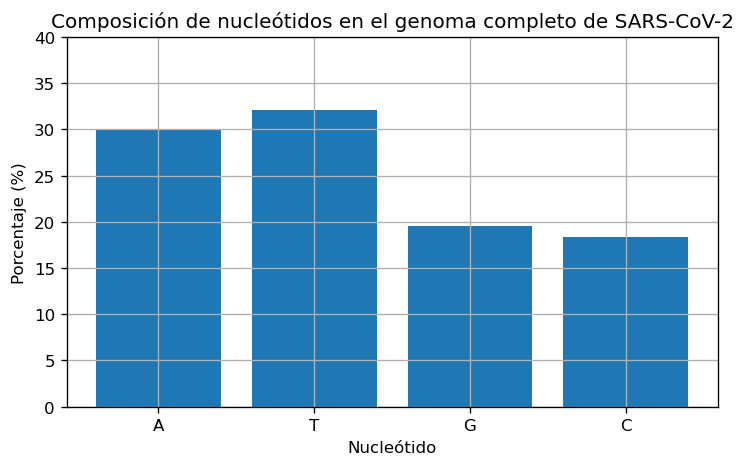

In [8]:
# ============================================================
# Gráfica de composición de nucleótidos
# ============================================================

plt.figure(figsize=(7, 4))
plt.bar(list("ATGC"), [base_percent[b] for b in "ATGC"])
plt.ylabel("Porcentaje (%)")
plt.xlabel("Nucleótido")
plt.title("Composición de nucleótidos en el genoma completo de SARS-CoV-2")
plt.ylim(0, 40)
plt.show()

In [9]:
# ============================================================
# 4. Verificación contra el artículo
# ============================================================

tolerancia = 0.05  # tolerancia en puntos porcentuales

for base in "ATGC":
    calculado = base_percent[base]
    reportado = valores_articulo[base]
    diferencia = abs(calculado - reportado)
    estado = "CUMPLE" if diferencia <= tolerancia else "REVISAR"
    print(f"{base}: calculado = {calculado:.2f}% | artículo = {reportado:.2f}% | diferencia = {diferencia:.4f}% | {estado}")


A: calculado = 29.94% | artículo = 29.94% | diferencia = 0.0035% | CUMPLE
T: calculado = 32.08% | artículo = 32.08% | diferencia = 0.0037% | CUMPLE
G: calculado = 19.61% | artículo = 19.61% | diferencia = 0.0033% | CUMPLE
C: calculado = 18.37% | artículo = 18.37% | diferencia = 0.0039% | CUMPLE


¿Qué es el odds ratio o estadístico rho?

En análisis de dinucleótidos, el odds ratio, también llamado estadístico rho (ρ), compara cuántas veces se observa un dinucleótido contra cuántas veces se esperaría encontrarlo si las bases estuvieran distribuidas al azar según sus frecuencias individuales.

Para un dinucleótido XY:

[ \rho_{XY}=\frac{f_{XY}}{f_X \times f_Y} ]

Donde:

(f_{XY}) es la frecuencia observada del dinucleótido XY.
(f_X) es la frecuencia del primer nucleótido.
(f_Y) es la frecuencia del segundo nucleótido.
Interpretación:

ρ ≈ 1: el dinucleótido aparece aproximadamente como se esperaba.
ρ < 1: el dinucleótido está subrepresentado.
ρ > 1: el dinucleótido está sobrerrepresentado.
En el artículo, el dinucleótido CG aparece muy reducido en SARS‑CoV‑2. Para el genoma completo se reportan 439 CG, frecuencia observada de 1.47%, frecuencia esperada de 3.60% y un odds ratio aproximado de 0.41.

In [10]:
# ============================================================
# 5. Funciones para calcular dinucleótidos y odds ratio/rho
# ============================================================

orden_articulo = ["GT", "GA", "GC", "GG",
                  "AG", "AT", "AC", "AA",
                  "TG", "TA", "TC", "TT",
                  "CG", "CA", "CT", "CC"]

def contar_dinucleotidos(seq):
    # Cuenta dinucleótidos traslapados en una secuencia.
    seq = limpiar_secuencia(seq)
    return Counter(seq[i:i+2] for i in range(len(seq) - 1))

def calcular_rho_dinucleotidos(seq):
    # Calcula frecuencia observada, frecuencia esperada y rho para los 16 dinucleótidos.
    seq = limpiar_secuencia(seq)
    total_bases = len(seq)
    total_dinucs = len(seq) - 1

    mono_counts = Counter(seq)
    dinuc_counts = contar_dinucleotidos(seq)

    resultados = []
    for dinuc in orden_articulo:
        x, y = dinuc[0], dinuc[1]
        f_x = mono_counts[x] / total_bases
        f_y = mono_counts[y] / total_bases
        f_obs = dinuc_counts[dinuc] / total_dinucs
        f_exp = f_x * f_y
        rho = f_obs / f_exp if f_exp > 0 else np.nan

        resultados.append({
            "Dinucleótido": dinuc,
            "Conteo observado": dinuc_counts[dinuc],
            "Frecuencia observada (%)": f_obs * 100,
            "Frecuencia esperada (%)": f_exp * 100,
            "Rho / odds ratio": rho
        })

    return pd.DataFrame(resultados).set_index("Dinucleótido")

rho_genoma_df = calcular_rho_dinucleotidos(genome_clean)
rho_genoma_df_rounded = rho_genoma_df.round({
    "Frecuencia observada (%)": 4,
    "Frecuencia esperada (%)": 4,
    "Rho / odds ratio": 4
})

display(rho_genoma_df_rounded)

,Conteo observado,Frecuencia observada (%),Frecuencia esperada (%),Rho / odds ratio
Dinucleótido,,,,
GT,1990,6.6551,6.2906,1.0579
GA,1612,5.3909,5.8709,0.9182
GC,1168,3.9061,3.6010,1.0847
GG,1093,3.6553,3.8442,0.9508
AG,1742,5.8257,5.8709,0.9923
AT,2308,7.7185,9.6070,0.8034
AC,2023,6.7654,5.4994,1.2302
AA,2880,9.6315,8.9661,1.0742
TG,2589,8.6583,6.2906,1.3764


In [11]:
# ============================================================
# Verificación específica de CG
# ============================================================

cg = rho_genoma_df.loc["CG"]

print("Resultados para CG en el genoma completo:")
print(f"Conteo observado de CG: {int(cg['Conteo observado'])}")
print(f"Frecuencia observada de CG: {cg['Frecuencia observada (%)']:.2f}%")
print(f"Frecuencia esperada de CG: {cg['Frecuencia esperada (%)']:.2f}%")
print(f"Odds ratio / rho de CG: {cg['Rho / odds ratio']:.2f}")

print("\nValores esperados de acuerdo con el artículo:")
print("Conteo CG = 439")
print("Frecuencia observada CG ≈ 1.47%")
print("Frecuencia esperada CG ≈ 3.60%")
print("Rho CG ≈ 0.41")

Resultados para CG en el genoma completo:
Conteo observado de CG: 439
Frecuencia observada de CG: 1.47%
Frecuencia esperada de CG: 3.60%
Odds ratio / rho de CG: 0.41

Valores esperados de acuerdo con el artículo:
Conteo CG = 439
Frecuencia observada CG ≈ 1.47%
Frecuencia esperada CG ≈ 3.60%
Rho CG ≈ 0.41


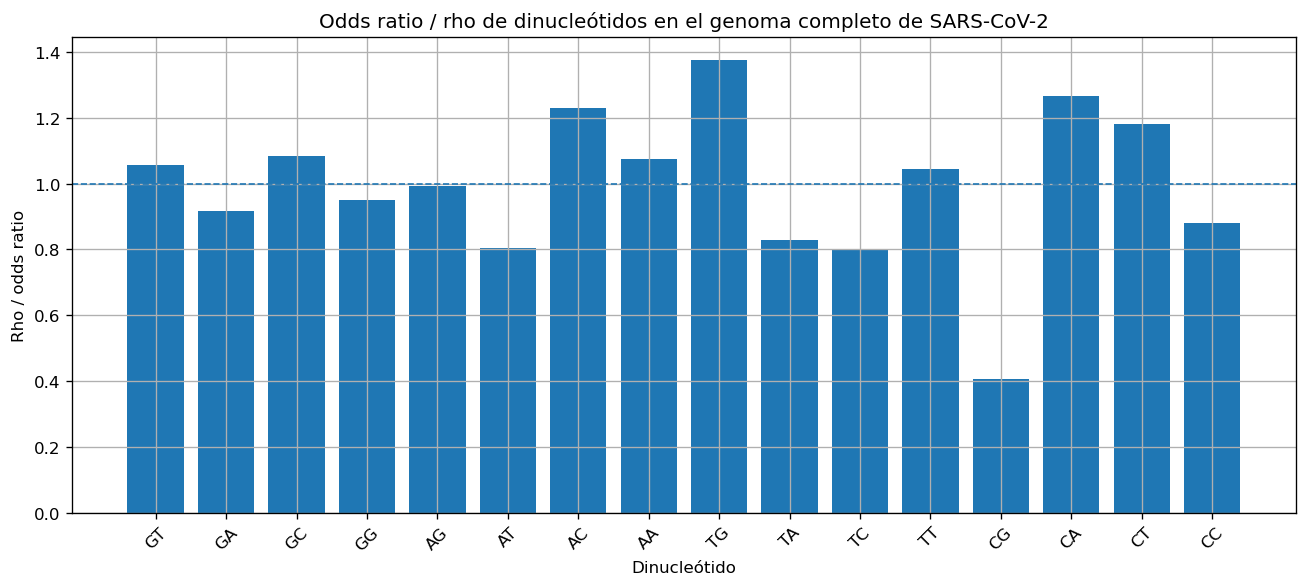

In [12]:
# ============================================================
# Gráfica de rho / odds ratio para los 16 dinucleótidos
# ============================================================

plt.figure(figsize=(11, 5))
plt.bar(rho_genoma_df.index, rho_genoma_df["Rho / odds ratio"])
plt.axhline(1, linestyle="--", linewidth=1)
plt.ylabel("Rho / odds ratio")
plt.xlabel("Dinucleótido")
plt.title("Odds ratio / rho de dinucleótidos en el genoma completo de SARS-CoV-2")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

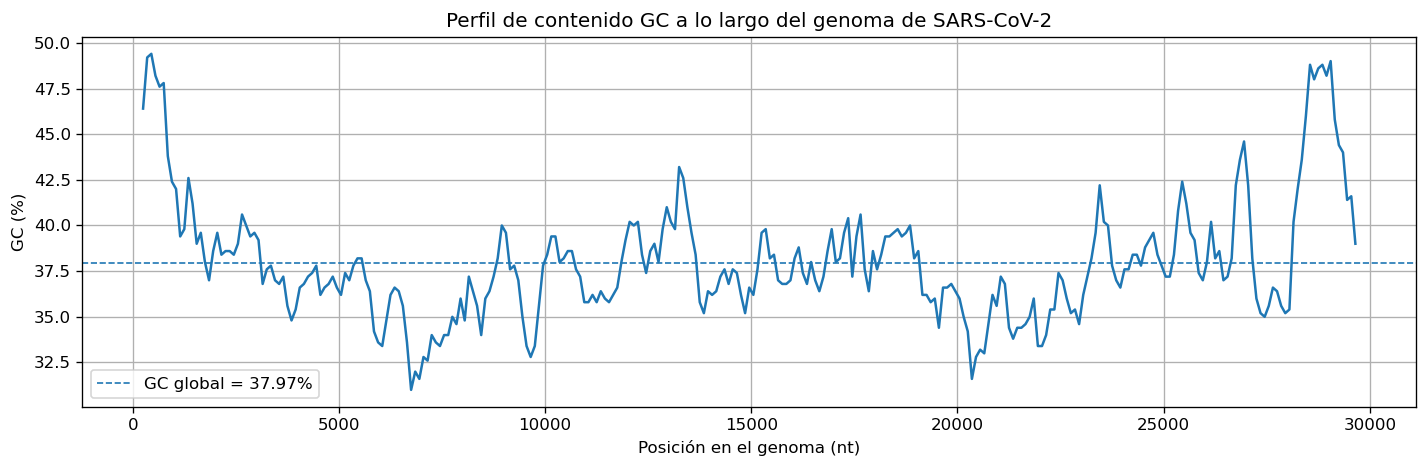

Número de ventanas analizadas: 295
GC mínimo en ventanas: 31.00%
GC máximo en ventanas: 49.40%
GC promedio en ventanas: 37.95%


In [13]:
# ============================================================
# 6. Perfil GC con ventana móvil
# ============================================================

def gc_ventanas(seq, ventana=500, paso=100):
    seq = limpiar_secuencia(seq)
    posiciones = []
    valores_gc = []

    for inicio in range(0, len(seq) - ventana + 1, paso):
        sub = seq[inicio:inicio + ventana]
        gc = (sub.count("G") + sub.count("C")) / len(sub) * 100
        centro = inicio + ventana // 2
        posiciones.append(centro)
        valores_gc.append(gc)

    return np.array(posiciones), np.array(valores_gc)

posiciones, valores_gc = gc_ventanas(genome_clean, ventana=500, paso=100)

plt.figure(figsize=(12, 4))
plt.plot(posiciones, valores_gc)
plt.axhline(gc_content, linestyle="--", linewidth=1, label=f"GC global = {gc_content:.2f}%")
plt.xlabel("Posición en el genoma (nt)")
plt.ylabel("GC (%)")
plt.title("Perfil de contenido GC a lo largo del genoma de SARS-CoV-2")
plt.legend()
plt.tight_layout()
plt.show()

print("Número de ventanas analizadas:", len(valores_gc))
print(f"GC mínimo en ventanas: {np.min(valores_gc):.2f}%")
print(f"GC máximo en ventanas: {np.max(valores_gc):.2f}%")
print(f"GC promedio en ventanas: {np.mean(valores_gc):.2f}%")

In [14]:
# ============================================================
# 7. Extraer secuencias codificantes del GenBank
# ============================================================

cds_records = []
protein_records = []
cds_info = []

for i, feature in enumerate(record.features, start=1):
    if feature.type != "CDS":
        continue

    qualifiers = feature.qualifiers

    gene = qualifiers.get("gene", qualifiers.get("locus_tag", [f"CDS_{i}"]))[0]
    product = qualifiers.get("product", ["producto_no_disponible"])[0]
    protein_id = qualifiers.get("protein_id", [f"protein_{i}"])[0]

    # feature.location usa coordenadas de Python, por eso start es 0-based.
    start = int(feature.location.start) + 1
    end = int(feature.location.end)
    strand = feature.location.strand

    cds_seq = limpiar_secuencia(feature.extract(record.seq))

    # Si GenBank ya trae traducción curada, usamos esa traducción.
    # Si no, traducimos directamente desde la secuencia codificante.
    if "translation" in qualifiers:
        protein_seq = qualifiers["translation"][0]
    else:
        protein_seq = str(Seq(cds_seq).translate(to_stop=True))

    cds_id = f"{gene}_{start}_{end}"

    cds_records.append(SeqRecord(
        Seq(cds_seq),
        id=cds_id,
        description=f"{product} | protein_id={protein_id}"
    ))

    protein_records.append(SeqRecord(
        Seq(protein_seq),
        id=cds_id,
        description=f"{product} | protein_id={protein_id}"
    ))

    cds_info.append({
        "CDS": cds_id,
        "Gen": gene,
        "Producto": product,
        "Protein ID": protein_id,
        "Inicio": start,
        "Fin": end,
        "Hebra": strand,
        "Longitud nt": len(cds_seq),
        "Longitud aa": len(protein_seq)
    })

cds_df = pd.DataFrame(cds_info)

cds_fasta = DATA_DIR / f"{ACCESSION}_secuencias_codificantes_CDS.fasta"
proteins_fasta = DATA_DIR / f"{ACCESSION}_proteinas_traducidas.fasta"

SeqIO.write(cds_records, cds_fasta, "fasta")
SeqIO.write(protein_records, proteins_fasta, "fasta")

print("Número de CDS encontradas:", len(cds_records))
print("CDS guardadas en:", cds_fasta.resolve())
print("Proteínas traducidas guardadas en:", proteins_fasta.resolve())

display(cds_df)

Número de CDS encontradas: 12
CDS guardadas en: /Users/valeriacontreras/Downloads/data_sars_cov_2/NC_045512.2_secuencias_codificantes_CDS.fasta
Proteínas traducidas guardadas en: /Users/valeriacontreras/Downloads/data_sars_cov_2/NC_045512.2_proteinas_traducidas.fasta


,CDS,Gen,Producto,Protein ID,Inicio,Fin,Hebra,Longitud nt,Longitud aa
0,ORF1ab_266_21555,ORF1ab,ORF1ab polyprotein,YP_009724389.1,266,21555,1,21291,7096
1,ORF1ab_266_13483,ORF1ab,ORF1a polyprotein,YP_009725295.1,266,13483,1,13218,4405
2,S_21563_25384,S,surface glycoprotein,YP_009724390.1,21563,25384,1,3822,1273
3,ORF3a_25393_26220,ORF3a,ORF3a protein,YP_009724391.1,25393,26220,1,828,275
4,E_26245_26472,E,envelope protein,YP_009724392.1,26245,26472,1,228,75
5,M_26523_27191,M,membrane glycoprotein,YP_009724393.1,26523,27191,1,669,222
6,ORF6_27202_27387,ORF6,ORF6 protein,YP_009724394.1,27202,27387,1,186,61
7,ORF7a_27394_27759,ORF7a,ORF7a protein,YP_009724395.1,27394,27759,1,366,121
8,ORF7b_27756_27887,ORF7b,ORF7b,YP_009725318.1,27756,27887,1,132,43
9,ORF8_27894_28259,ORF8,ORF8 protein,YP_009724396.1,27894,28259,1,366,121


In [15]:
# ============================================================
# 8. Rho / odds ratio en las secuencias codificantes
# ============================================================

cds_concatenadas = "".join(str(rec.seq) for rec in cds_records)
rho_cds_df = calcular_rho_dinucleotidos(cds_concatenadas)

print("Longitud total concatenada de CDS:", len(cds_concatenadas), "nt")
display(rho_cds_df.round({
    "Frecuencia observada (%)": 4,
    "Frecuencia esperada (%)": 4,
    "Rho / odds ratio": 4
}))

print("\nCG en CDS concatenadas:")
print(f"Conteo CG: {int(rho_cds_df.loc['CG', 'Conteo observado'])}")
print(f"Rho CG en CDS: {rho_cds_df.loc['CG', 'Rho / odds ratio']:.3f}")
print("\nNota: el artículo reporta rho de CG en ORFs ≈ 0.39. Puede variar ligeramente según cómo se manejen CDS solapadas y ORF1ab.")


Longitud total concatenada de CDS: 42483 nt


,Conteo observado,Frecuencia observada (%),Frecuencia esperada (%),Rho / odds ratio
Dinucleótido,,,,
GT,2898,6.8217,6.3752,1.0700
GA,2274,5.3529,5.9004,0.9072
GC,1643,3.8675,3.5775,1.0811
GG,1577,3.7122,3.9030,0.9511
AG,2503,5.8919,5.9004,0.9986
AT,3235,7.6150,9.6376,0.7901
AC,2865,6.7440,5.4083,1.2470
AA,4085,9.6158,8.9198,1.0780
TG,3738,8.7990,6.3752,1.3802



CG en CDS concatenadas:
Conteo CG: 575
Rho CG en CDS: 0.378

Nota: el artículo reporta rho de CG en ORFs ≈ 0.39. Puede variar ligeramente según cómo se manejen CDS solapadas y ORF1ab.


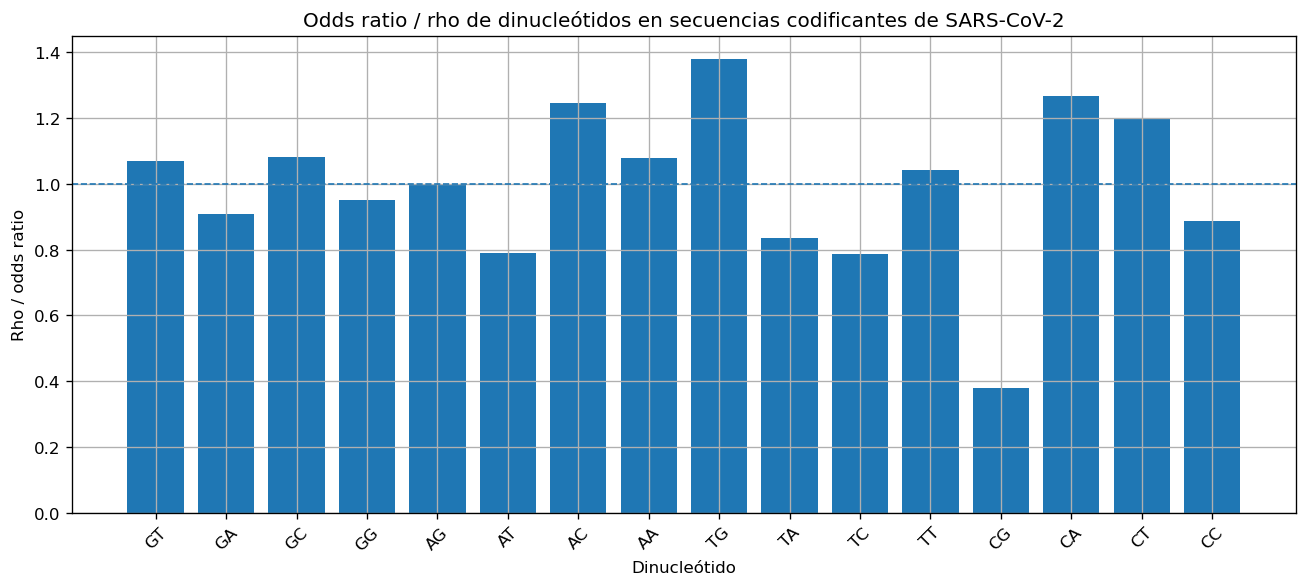

In [16]:
# ============================================================
# Gráfica de rho en secuencias codificantes
# ============================================================

plt.figure(figsize=(11, 5))
plt.bar(rho_cds_df.index, rho_cds_df["Rho / odds ratio"])
plt.axhline(1, linestyle="--", linewidth=1)
plt.ylabel("Rho / odds ratio")
plt.xlabel("Dinucleótido")
plt.title("Odds ratio / rho de dinucleótidos en secuencias codificantes de SARS-CoV-2")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# 9. Rho por posiciones del codón
# ============================================================

def rho_por_pares_posicion(cds_records):
    # Calcula rho para dinucleótidos en posiciones 12, 23 y 31 del codón.
    resultados = {}

    for tipo in ["12", "23", "31"]:
        dinucs = []

        for rec in cds_records:
            seq = limpiar_secuencia(str(rec.seq))
            # Recortar a codones completos
            seq = seq[:len(seq) - (len(seq) % 3)]
            codones = [seq[i:i+3] for i in range(0, len(seq), 3)]

            if tipo == "12":
                pares = [codon[0:2] for codon in codones if len(codon) == 3]
            elif tipo == "23":
                pares = [codon[1:3] for codon in codones if len(codon) == 3]
            else:  # tipo == "31", atraviesa frontera de codones
                pares = [codones[i][2] + codones[i+1][0] for i in range(len(codones) - 1)]

            dinucs.extend(pares)

        total = len(dinucs)
        conteos = Counter(dinucs)
        primeras = [d[0] for d in dinucs]
        segundas = [d[1] for d in dinucs]
        conteos_primeras = Counter(primeras)
        conteos_segundas = Counter(segundas)

        filas = []
        for dinuc in orden_articulo:
            x, y = dinuc[0], dinuc[1]
            f_obs = conteos[dinuc] / total if total > 0 else np.nan
            f_exp = (conteos_primeras[x] / total) * (conteos_segundas[y] / total) if total > 0 else np.nan
            rho = f_obs / f_exp if f_exp and f_exp > 0 else np.nan
            filas.append({
                "Dinucleótido": dinuc,
                "Posición": tipo,
                "Conteo observado": conteos[dinuc],
                "Rho / odds ratio": rho
            })

        resultados[tipo] = pd.DataFrame(filas).set_index("Dinucleótido")

    return resultados

rho_pos = rho_por_pares_posicion(cds_records)

for tipo, df in rho_pos.items():
    print(f"\nPosición {tipo}:")
    display(df[["Conteo observado", "Rho / odds ratio"]].round(4))
    print(f"Rho de CG en posición {tipo}: {df.loc['CG', 'Rho / odds ratio']:.3f}")


Posición 12:


,Conteo observado,Rho / odds ratio
Dinucleótido,,
GT,1152,0.8769
GA,1403,1.0258
GC,967,0.9639
GG,840,1.2401
AG,564,0.8506
AT,1040,0.8087
AC,1063,1.0824
AA,1603,1.1973
TG,592,1.1748


Rho de CG en posición 12: 0.572

Posición 23:


,Conteo observado,Rho / odds ratio
Dinucleótido,,
GT,1204,1.2508
GA,399,0.6459
GC,335,1.0025
GG,261,0.9175
AG,649,1.1299
AT,1550,0.7975
AC,844,1.2509
AA,1397,1.1201
TG,798,1.4463


Rho de CG en posición 23: 0.294

Posición 31:


,Conteo observado,Rho / odds ratio
Dinucleótido,,
GT,542,1.2907
GA,472,0.8566
GC,341,1.1537
GG,476,0.8433
AG,1290,1.0548
AT,645,0.7089
AC,958,1.4960
AA,1074,0.8996
TG,2348,1.2286


Rho de CG en posición 31: 0.374


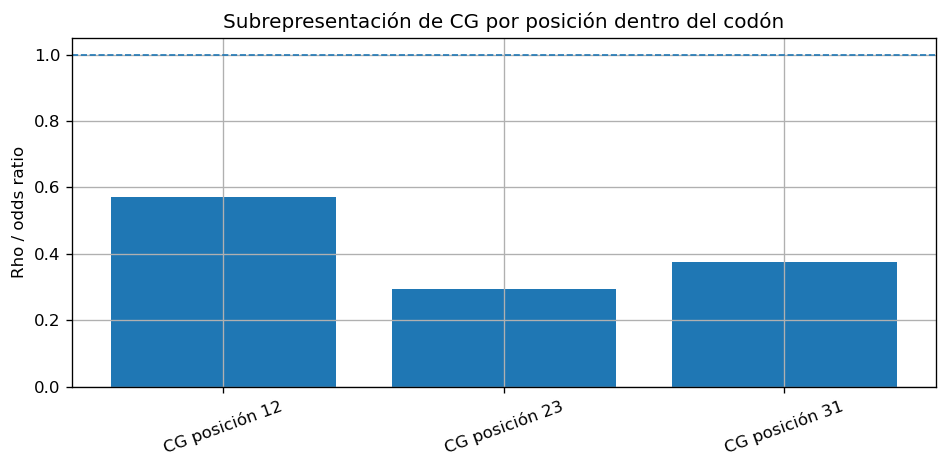

CG posición 12    0.5724
CG posición 23    0.2943
CG posición 31    0.3738
dtype: float64

In [18]:
# ============================================================
# Gráfica comparativa de rho de CG por posición del codón
# ============================================================

cg_posiciones = pd.Series({
    "CG posición 12": rho_pos["12"].loc["CG", "Rho / odds ratio"],
    "CG posición 23": rho_pos["23"].loc["CG", "Rho / odds ratio"],
    "CG posición 31": rho_pos["31"].loc["CG", "Rho / odds ratio"]
})

plt.figure(figsize=(8, 4))
plt.bar(cg_posiciones.index, cg_posiciones.values)
plt.axhline(1, linestyle="--", linewidth=1)
plt.ylabel("Rho / odds ratio")
plt.title("Subrepresentación de CG por posición dentro del codón")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(cg_posiciones.round(4))

In [19]:
# ============================================================
# 10. Mostrar traducciones de CDS a proteínas
# ============================================================

proteinas_df = pd.DataFrame({
    "ID": [rec.id for rec in protein_records],
    "Longitud aa": [len(rec.seq) for rec in protein_records],
    "Primeros 60 aa": [str(rec.seq)[:60] for rec in protein_records]
})

display(proteinas_df)

print("Ejemplo de una proteína traducida en formato FASTA:\n")
print(protein_records[0].format("fasta")[:1000])

,ID,Longitud aa,Primeros 60 aa
0,ORF1ab_266_21555,7096,MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHL...
1,ORF1ab_266_13483,4405,MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHL...
2,S_21563_25384,1273,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
3,ORF3a_25393_26220,275,MDLFMRIFTIGTVTLKQGEIKDATPSDFVRATATIPIQASLPFGWL...
4,E_26245_26472,75,MYSFVSEETGTLIVNSVLLFLAFVVFLLVTLAILTALRLCAYCCNI...
5,M_26523_27191,222,MADSNGTITVEELKKLLEQWNLVIGFLFLTWICLLQFAYANRNRFL...
6,ORF6_27202_27387,61,MFHLVDFQVTIAEILLIIMRTFKVSIWNLDYIINLIIKNLSKSLTE...
7,ORF7a_27394_27759,121,MKIILFLALITLATCELYHYQECVRGTTVLLKEPCSSGTYEGNSPF...
8,ORF7b_27756_27887,43,MIELSLIDFYLCFLAFLLFLVLIMLIIFWFSLELQDHNETCHA
9,ORF8_27894_28259,121,MKFLVFLGIITTVAAFHQECSLQSCTQHQPYVVDDPCPIHFYSKWY...


Ejemplo de una proteína traducida en formato FASTA:

>ORF1ab_266_21555 ORF1ab polyprotein | protein_id=YP_009724389.1
MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHLKDGTCGLVEVEKGV
LPQLEQPYVFIKRSDARTAPHGHVMVELVAELEGIQYGRSGETLGVLVPHVGEIPVAYRK
VLLRKNGNKGAGGHSYGADLKSFDLGDELGTDPYEDFQENWNTKHSSGVTRELMRELNGG
AYTRYVDNNFCGPDGYPLECIKDLLARAGKASCTLSEQLDFIDTKRGVYCCREHEHEIAW
YTERSEKSYELQTPFEIKLAKKFDTFNGECPNFVFPLNSIIKTIQPRVEKKKLDGFMGRI
RSVYPVASPNECNQMCLSTLMKCDHCGETSWQTGDFVKATCEFCGTENLTKEGATTCGYL
PQNAVVKIYCPACHNSEVGPEHSLAEYHNESGLKTILRKGGRTIAFGGCVFSYVGCHNKC
AYWVPRASANIGCNHTGVVGEGSEGLNDNLLEILQKEKVNINIVGDFKLNEEIAIILASF
SASTSAFVETVKGLDYKAFKQIVESCGNFKVTKGKAKKGAWNIGEQKSILSPLYAFASEA
ARVVRSIFSRTLETAQNSVRVLQKAAITILDGISQYSLRLIDAMMFTSDLATNNLVVMAY
ITGGVVQLTSQWLTNIFGTVYEKLKPVLDWLEEKFKEGVEFLRDGWEIVKFISTCACEIV
GGQIVTCAKEIKESVQTFFKLVNKFLALCADSIIIGGAKLKALNLGETFVTHSKGLYRKC
VKSREETGLLMPLKAPKEIIFLEGETLPTEVLTEEVVLKTGDLQPLEQPTSEAVEAPLVG
TPVCINGLMLLEIKDTEKYCALAPNMMVTNNTFTLKGGAPTKVTFGDDTVIEVQGYKSVN
ITFELDERIDKVLNEKCSAYTVELGTEV

Discusión de Resultados y Conclusiones
    1.Validación de la Composición de Nucleótidos
Al analizar el genoma completo de referencia de SARS-CoV-2 (NC_045512), los porcentajes de nucleótidos obtenidos mediante Biopython muestran un sesgo muy marcado hacia un alto contenido de Adenina (A) y Timina (T)/Uracilo (U), sumando más del 60% del genoma, en contraste con una baja proporción de Guanina (G) y Citosina (C). Estos valores calculados coinciden con lo reportado por Wang et al. (2020) en el artículo de Nature, donde se detalla que la composición global es aproximadamente de 29.94% de A, 32.08% de T, 19.61% de G y 18.37% de C.
    2. Subrepresentación del Dinucleótido CG (Estadístico Rho)
    El análisis del Odds Ratio (estadístico $\rho$) para los 16 dinucleótidos posibles revela que el par CG presenta una deficiencia extrema en el genoma completo del virus, alcanzando un valor de ~0.41. Un valor de $\rho = 1.0$ representaría una abundancia idéntica a la esperada por el puro azar matemático basado en la cantidad de C y G individuales. Al ser notablemente menor a 1.0, se demuestra estadísticamente que existe una fuerza evolutiva que suprime de forma activa la presencia de dinucleótidos CG en las regiones del virus.
    3. Explicación Biológica de la Reducción de CG en los ORFs
La hipótesis principal del artículo señala que el SARS-CoV-2 ha evolucionado reduciendo drásticamente los dinucleótidos CG en sus marcos abiertos de lectura (ORFs) debido a dos presiones de selección fundamentales:
        Evasión del Sistema Inmune del Hospedero: Las células humanas cuentan con mecanismos de defensa capaces de reconocer ARN o ADN viral rico en motivos CpG (como la proteína ZAP o los receptores TLR9), desencadenando una respuesta inmunitaria antiviral (interferón). Al "mimetizar" la baja abundancia de CG típica de los ARNm del genoma humano, el virus logra pasar desapercibido y evadir la degradación de su material genético.
        Optimización Energética de la Replicación y Traducción: Los enlaces entre Citosina y Guanina (C-G) poseen tres puentes de hidrógeno, lo que los hace estructuralmente más fuertes y estables que los enlaces A-T (que solo tienen dos). Al mutar deliberadamente las posiciones de C/G hacia A/T, las cadenas de ARN viral requieren menos energía cinética y térmica para romper sus estructuras secundarias (bucles o stem-loops). Esto facilita que la ARN polimerasa viral y los ribosomas del hospedero se desplacen de forma mucho más rápida y eficiente durante la replicación y la síntesis de proteínas.
    4. Excepción Biológica: La Región 5'-UTRA pesar de la tendencia generalizada de reducir los niveles de CG, el estudio resalta que la región 5' no traducida (5'-UTR) del SARS-CoV-2 conserva un contenido de CG inusualmente alto. Esto no es un error evolutivo, sino una adaptación crucial: el virus necesita de la estabilidad estructural que aportan los enlaces C-G en el extremo 5' para conformar un Sitio Interno de Entrada al Ribosoma (IRES). Esta compleja estructura tridimensional es indispensable para reclutar y secuestrar eficazmente los ribosomas de la célula humana, garantizando que los genes del virus se traduzcan con absoluta prioridad sobre los genes normales de la célula hospedera.

In [20]:
# ============================================================
# 11. Resumen final automático
# ============================================================

print("="*80)
print("RESUMEN FINAL DEL PROYECTO 5")
print("="*80)
print(f"Acceso analizado: {ACCESSION}")
print(f"Longitud del genoma: {n:,} nt")
print(f"A: {base_percent['A']:.2f}%")
print(f"T: {base_percent['T']:.2f}%")
print(f"G: {base_percent['G']:.2f}%")
print(f"C: {base_percent['C']:.2f}%")
print(f"GC total: {gc_content:.2f}%")
print(f"Conteo CG genoma completo: {int(rho_genoma_df.loc['CG', 'Conteo observado'])}")
print(f"Rho CG genoma completo: {rho_genoma_df.loc['CG', 'Rho / odds ratio']:.3f}")
print(f"Número de CDS extraídas: {len(cds_records)}")
print(f"Archivo genoma completo: {genome_fasta}")
print(f"Archivo CDS: {cds_fasta}")
print(f"Archivo proteínas: {proteins_fasta}")
print("="*80)

RESUMEN FINAL DEL PROYECTO 5
Acceso analizado: NC_045512.2
Longitud del genoma: 29,903 nt
A: 29.94%
T: 32.08%
G: 19.61%
C: 18.37%
GC total: 37.97%
Conteo CG genoma completo: 439
Rho CG genoma completo: 0.408
Número de CDS extraídas: 12
Archivo genoma completo: data_sars_cov_2/NC_045512.2_genoma_completo.fasta
Archivo CDS: data_sars_cov_2/NC_045512.2_secuencias_codificantes_CDS.fasta
Archivo proteínas: data_sars_cov_2/NC_045512.2_proteinas_traducidas.fasta
